# Fase 4 — Visualización, validación y comunicación de resultados

## Proyecto: Impacto de la inteligencia artificial en el empleo, la productividad y la capacitación laboral

Este notebook corresponde a la Fase 4 del proyecto final integrador del curso MCD1500 — Programación para la Ciencia de Datos. Su propósito es consolidar los avances desarrollados en las fases anteriores, validar técnicamente el flujo de análisis, construir visualizaciones interpretables y comunicar hallazgos relevantes de manera clara y reproducible.

La Fase 4 integra el dataset limpio generado en Fase 2, el núcleo algorítmico y la arquitectura modular desarrollada en Fase 3, y produce evidencias visuales y documentales para el informe técnico final y la presentación profesional.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ruta raíz del proyecto
PROJECT_ROOT = Path.cwd().parents[1]

# Rutas principales
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" / "ai_job_impact_clean.csv"
F3_SRC = PROJECT_ROOT / "F3" / "src"
F4_SRC = PROJECT_ROOT / "F4" / "src"
F4_RESULTS = PROJECT_ROOT / "F4" / "results"

# Agregar scripts al path
for ruta in [F3_SRC, F4_SRC]:
    if str(ruta) not in sys.path:
        sys.path.append(str(ruta))

print("Ruta del proyecto:", PROJECT_ROOT)
print("Dataset procesado:", DATA_PROCESSED)
print("Resultados F4:", F4_RESULTS)

Ruta del proyecto: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6
Dataset procesado: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\data\processed\ai_job_impact_clean.csv
Resultados F4: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F4\results


In [2]:
df = pd.read_csv(DATA_PROCESSED)

print("Dataset cargado correctamente")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

Dataset cargado correctamente
Filas: 2000
Columnas: 17


,employee_id,age,gender,education_level,industry,job_role,years_experience,ai_adoption_level,automation_risk,upskilling_required,salary_before_ai,salary_after_ai,job_status,work_hours_per_week,remote_work,job_satisfaction,productivity_change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03


In [3]:
validacion_inicial = {
    "filas": df.shape[0],
    "columnas": df.shape[1],
    "valores_nulos": int(df.isnull().sum().sum()),
    "duplicados": int(df.duplicated().sum()),
    "variable_objetivo": "salary_after_ai",
    "existe_salary_after_ai": "salary_after_ai" in df.columns
}

validacion_inicial

{'filas': 2000,
 'columnas': 17,
 'valores_nulos': 0,
 'duplicados': 0,
 'variable_objetivo': 'salary_after_ai',
 'existe_salary_after_ai': True}

In [4]:
assert validacion_inicial["filas"] == 2000
assert validacion_inicial["columnas"] == 17
assert validacion_inicial["valores_nulos"] == 0
assert validacion_inicial["duplicados"] == 0
assert validacion_inicial["existe_salary_after_ai"] is True

print("Validación inicial F4 ejecutada correctamente.")

Validación inicial F4 ejecutada correctamente.


## Visualizaciones analíticas de Fase 4

En esta sección se construyen visualizaciones orientadas a comunicar hallazgos relevantes del proyecto. Cada figura responde a una pregunta analítica específica y se guarda como archivo PNG en la carpeta `F4/results`, asegurando trazabilidad entre notebook, resultados e informe final.

Las visualizaciones seleccionadas permiten analizar relaciones entre adopción de inteligencia artificial, salario posterior a IA, productividad, riesgo de automatización y variables laborales relevantes.

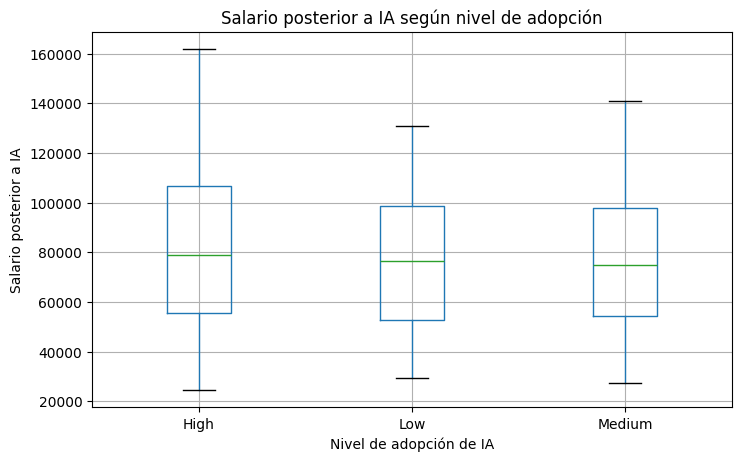

Figura guardada en: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F4\results\figura_1_salario_por_adopcion_ia.png


In [5]:
# Figura 1: salario posterior a IA según nivel de adopción de IA

fig, ax = plt.subplots(figsize=(8, 5))

df.boxplot(
    column="salary_after_ai",
    by="ai_adoption_level",
    ax=ax
)

ax.set_title("Salario posterior a IA según nivel de adopción")
ax.set_xlabel("Nivel de adopción de IA")
ax.set_ylabel("Salario posterior a IA")
fig.suptitle("")

ruta_figura_1 = F4_RESULTS / "figura_1_salario_por_adopcion_ia.png"
plt.savefig(ruta_figura_1, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada en:", ruta_figura_1)

**Interpretación de la Figura 1.**  
El gráfico compara la distribución del salario posterior a la adopción de inteligencia artificial según el nivel de adopción de IA. Esta visualización permite observar diferencias en la mediana, dispersión y posibles valores atípicos entre grupos. Su propósito es evaluar si los trabajadores asociados a mayores niveles de adopción tecnológica presentan diferencias salariales relevantes respecto de quienes se ubican en niveles de adopción menores.

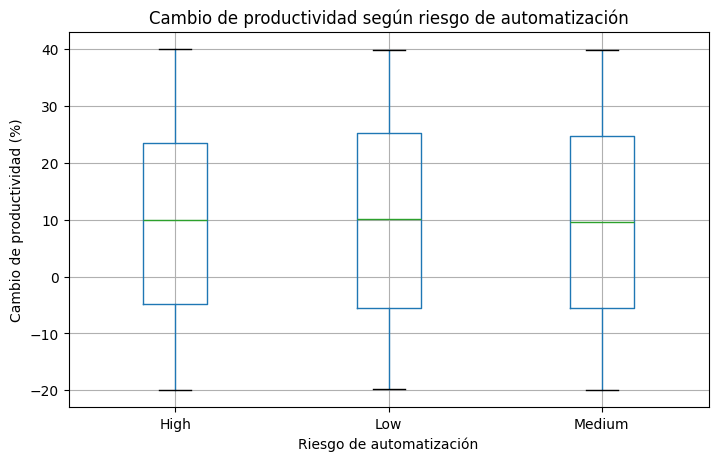

Figura guardada en: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F4\results\figura_2_productividad_por_riesgo.png


In [6]:
# Figura 2: cambio de productividad según riesgo de automatización

fig, ax = plt.subplots(figsize=(8, 5))

df.boxplot(
    column="productivity_change_%",
    by="automation_risk",
    ax=ax
)

ax.set_title("Cambio de productividad según riesgo de automatización")
ax.set_xlabel("Riesgo de automatización")
ax.set_ylabel("Cambio de productividad (%)")
fig.suptitle("")

ruta_figura_2 = F4_RESULTS / "figura_2_productividad_por_riesgo.png"
plt.savefig(ruta_figura_2, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada en:", ruta_figura_2)

**Interpretación de la Figura 2.**  
El gráfico muestra la distribución del cambio de productividad según el nivel de riesgo de automatización. Esta comparación permite explorar si los grupos con mayor riesgo presentan comportamientos distintos en productividad, lo cual se relaciona directamente con la problemática del proyecto sobre los efectos de la inteligencia artificial en el empleo y el desempeño laboral.

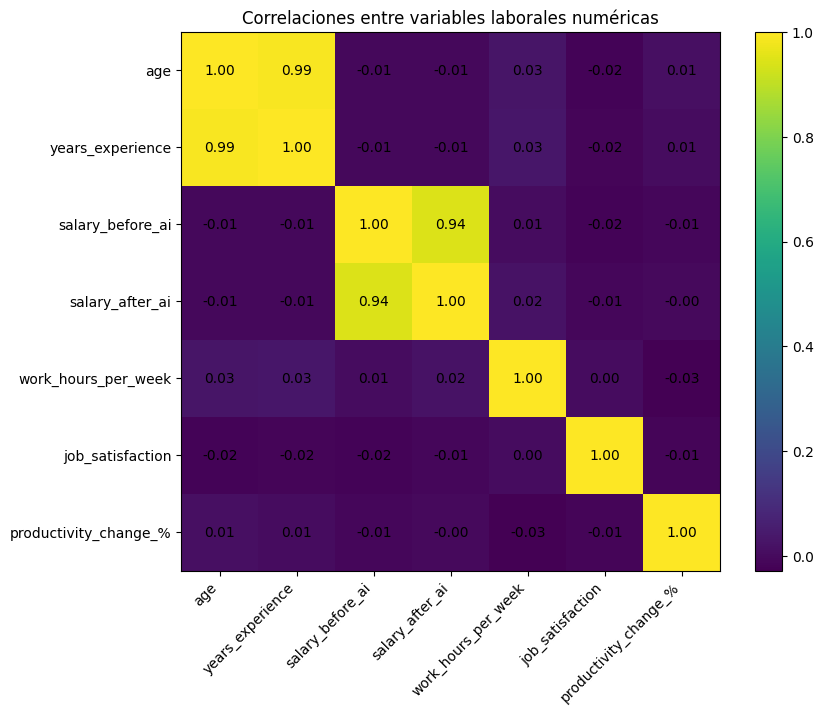

Figura guardada en: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F4\results\figura_3_correlaciones_laborales.png


In [7]:
# Figura 3: matriz de correlaciones entre variables laborales numéricas

columnas_correlacion = [
    "age",
    "years_experience",
    "salary_before_ai",
    "salary_after_ai",
    "work_hours_per_week",
    "job_satisfaction",
    "productivity_change_%"
]

corr = df[columnas_correlacion].corr()

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(corr)

ax.set_xticks(range(len(columnas_correlacion)))
ax.set_yticks(range(len(columnas_correlacion)))
ax.set_xticklabels(columnas_correlacion, rotation=45, ha="right")
ax.set_yticklabels(columnas_correlacion)

for i in range(len(columnas_correlacion)):
    for j in range(len(columnas_correlacion)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Correlaciones entre variables laborales numéricas")
fig.colorbar(im, ax=ax)

ruta_figura_3 = F4_RESULTS / "figura_3_correlaciones_laborales.png"
plt.savefig(ruta_figura_3, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada en:", ruta_figura_3)

**Interpretación de la Figura 3.**  
El mapa de correlaciones permite identificar relaciones lineales entre variables laborales numéricas del proyecto. En particular, permite observar cómo se asocian variables como salario antes de IA, salario después de IA, experiencia laboral, horas de trabajo, satisfacción y cambio de productividad. Esta visualización ayuda a distinguir asociaciones fuertes, relaciones débiles y posibles variables relevantes para análisis posteriores o discusión de resultados.

In [8]:
# Exportación de resumen de hallazgos F4

resumen_hallazgos = """
Resumen de hallazgos visuales - Fase 4
======================================

Figura 1: Salario posterior a IA según nivel de adopción
Esta visualización permite comparar la distribución salarial entre distintos niveles de adopción de inteligencia artificial, observando diferencias en mediana, dispersión y posibles valores atípicos.

Figura 2: Cambio de productividad según riesgo de automatización
Esta visualización permite analizar si los niveles de riesgo de automatización se asocian con diferencias en el cambio de productividad reportado.

Figura 3: Correlaciones entre variables laborales numéricas
El mapa de correlaciones permite examinar asociaciones lineales entre variables como edad, experiencia, salarios, horas de trabajo, satisfacción laboral y productividad.

Conclusión preliminar:
Las visualizaciones fortalecen la comunicación de hallazgos al vincular el análisis técnico con la problemática central del proyecto: el impacto de la inteligencia artificial en el empleo, la productividad y la capacitación laboral.
"""

ruta_resumen = F4_RESULTS / "resumen_hallazgos_f4.txt"

with open(ruta_resumen, "w", encoding="utf-8") as archivo:
    archivo.write(resumen_hallazgos)

print("Resumen de hallazgos guardado en:", ruta_resumen)

Resumen de hallazgos guardado en: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F4\results\resumen_hallazgos_f4.txt


## Validación técnica y documentación arquitectónica

En esta sección se registran métricas de validación técnica y una síntesis de la arquitectura utilizada en Fase 4. El propósito es dejar evidencia reproducible del estado del dataset, las salidas generadas, las visualizaciones construidas y la relación entre los componentes del repositorio.

Esta documentación fortalece la trazabilidad del proyecto y permite vincular el trabajo técnico realizado con los criterios de reproducibilidad, calidad y comunicación profesional exigidos en la Fase 4.

In [9]:
# Métricas de validación técnica F4

metricas_validacion = {
    "filas_dataset": df.shape[0],
    "columnas_dataset": df.shape[1],
    "valores_nulos_totales": int(df.isnull().sum().sum()),
    "registros_duplicados": int(df.duplicated().sum()),
    "existe_variable_objetivo_salary_after_ai": "salary_after_ai" in df.columns,
    "figura_1_generada": (F4_RESULTS / "figura_1_salario_por_adopcion_ia.png").exists(),
    "figura_2_generada": (F4_RESULTS / "figura_2_productividad_por_riesgo.png").exists(),
    "figura_3_generada": (F4_RESULTS / "figura_3_correlaciones_laborales.png").exists(),
    "resumen_hallazgos_generado": (F4_RESULTS / "resumen_hallazgos_f4.txt").exists()
}

metricas_validacion

{'filas_dataset': 2000,
 'columnas_dataset': 17,
 'valores_nulos_totales': 0,
 'registros_duplicados': 0,
 'existe_variable_objetivo_salary_after_ai': True,
 'figura_1_generada': True,
 'figura_2_generada': True,
 'figura_3_generada': True,
 'resumen_hallazgos_generado': True}

In [10]:
# Validaciones formales F4

assert metricas_validacion["filas_dataset"] == 2000
assert metricas_validacion["columnas_dataset"] == 17
assert metricas_validacion["valores_nulos_totales"] == 0
assert metricas_validacion["registros_duplicados"] == 0
assert metricas_validacion["existe_variable_objetivo_salary_after_ai"] is True
assert metricas_validacion["figura_1_generada"] is True
assert metricas_validacion["figura_2_generada"] is True
assert metricas_validacion["figura_3_generada"] is True
assert metricas_validacion["resumen_hallazgos_generado"] is True

print("Validaciones técnicas F4 ejecutadas correctamente.")

Validaciones técnicas F4 ejecutadas correctamente.


In [11]:
# Exportación de métricas de validación F4

ruta_metricas = F4_RESULTS / "metricas_validacion_f4.txt"

with open(ruta_metricas, "w", encoding="utf-8") as archivo:
    archivo.write("Métricas de validación técnica - Fase 4\n")
    archivo.write("=======================================\n\n")

    for clave, valor in metricas_validacion.items():
        archivo.write(f"{clave}: {valor}\n")

    archivo.write("\nInterpretación:\n")
    archivo.write(
        "Las métricas confirman que el dataset mantiene consistencia estructural, "
        "sin valores nulos ni duplicados, y que las visualizaciones principales "
        "fueron generadas correctamente en la carpeta F4/results.\n"
    )

print("Métricas guardadas en:", ruta_metricas)

Métricas guardadas en: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F4\results\metricas_validacion_f4.txt


In [12]:
# Documentación arquitectónica F4

documentacion_arquitectura = """
Documentación arquitectónica - Fase 4
=====================================

Objetivo:
La Fase 4 consolida el cierre integrador del proyecto, articulando el dataset limpio generado en Fase 2, el núcleo algorítmico y modular desarrollado en Fase 3, y las visualizaciones analíticas orientadas a comunicar hallazgos relevantes.

Entradas:
- data/processed/ai_job_impact_clean.csv
- F3/src/algoritmos_f3.py
- F3/results/mediciones_complejidad_f3.txt
- F3/results/comparacion_tiempos_f3.png

Proceso:
1. Carga del dataset limpio.
2. Validación de estructura, nulos, duplicados y variable objetivo.
3. Construcción de visualizaciones analíticas.
4. Exportación de figuras a F4/results.
5. Registro de resumen de hallazgos.
6. Registro de métricas de validación técnica.

Salidas:
- F4/results/figura_1_salario_por_adopcion_ia.png
- F4/results/figura_2_productividad_por_riesgo.png
- F4/results/figura_3_correlaciones_laborales.png
- F4/results/resumen_hallazgos_f4.txt
- F4/results/metricas_validacion_f4.txt

Arquitectura:
Fase 2 entrega el dataset limpio.
Fase 3 entrega el núcleo algorítmico, validación de complejidad, POO y resultados de eficiencia.
Fase 4 integra los resultados previos, construye visualizaciones y comunica hallazgos para el cierre técnico del proyecto.

Criterio de trazabilidad:
Cada salida generada queda almacenada en F4/results y puede ser vinculada directamente con el notebook F4_visualizacion_validacion_cierre.ipynb.

Buenas prácticas aplicadas:
- Uso de rutas reproducibles mediante pathlib.
- Separación de carpetas por fase.
- Validaciones con assert.
- Exportación persistente de resultados.
- Documentación narrativa en notebook.
- Control de versiones mediante Git y GitHub.
"""

ruta_documentacion = F4_RESULTS / "documentacion_arquitectura_f4.txt"

with open(ruta_documentacion, "w", encoding="utf-8") as archivo:
    archivo.write(documentacion_arquitectura)

print("Documentación arquitectónica guardada en:", ruta_documentacion)

Documentación arquitectónica guardada en: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F4\results\documentacion_arquitectura_f4.txt


## Visualizaciones adicionales y modularización

En esta sección se incorporan visualizaciones adicionales mediante funciones reutilizables definidas en `F4/src/visualizaciones_f4.py`. Esta mejora permite avanzar desde un notebook funcional hacia una arquitectura más modular, trazable y mantenible.

Las nuevas figuras refuerzan la comunicación de hallazgos desde tres perspectivas: distribución general del salario posterior a IA, comparación del salario promedio por nivel de adopción tecnológica y relación entre salario antes y después de IA según riesgo de automatización.

In [13]:
from visualizaciones_f4 import (
    graficar_distribucion_salario_after_ai,
    graficar_promedio_salario_por_adopcion,
    graficar_salario_antes_vs_despues_por_riesgo
)

In [14]:
# Generación de visualizaciones adicionales mediante funciones modularizadas

ruta_figura_4 = graficar_distribucion_salario_after_ai(
    df=df,
    ruta_salida=F4_RESULTS / "figura_4_distribucion_salario_after_ai.png"
)

ruta_figura_5 = graficar_promedio_salario_por_adopcion(
    df=df,
    ruta_salida=F4_RESULTS / "figura_5_promedio_salario_por_adopcion.png"
)

ruta_figura_6 = graficar_salario_antes_vs_despues_por_riesgo(
    df=df,
    ruta_salida=F4_RESULTS / "figura_6_salario_antes_vs_despues_por_riesgo.png"
)

print("Figura 4 guardada en:", ruta_figura_4)
print("Figura 5 guardada en:", ruta_figura_5)
print("Figura 6 guardada en:", ruta_figura_6)

Figura 4 guardada en: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F4\results\figura_4_distribucion_salario_after_ai.png
Figura 5 guardada en: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F4\results\figura_5_promedio_salario_por_adopcion.png
Figura 6 guardada en: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F4\results\figura_6_salario_antes_vs_despues_por_riesgo.png


In [15]:
# Validación de generación de visualizaciones adicionales

assert ruta_figura_4.exists()
assert ruta_figura_5.exists()
assert ruta_figura_6.exists()

print("Visualizaciones adicionales generadas correctamente.")

Visualizaciones adicionales generadas correctamente.


**Interpretación de las visualizaciones adicionales.**

La Figura 4 permite observar la distribución general de `salary_after_ai`, identificando concentración, dispersión y posibles asimetrías en el salario posterior a la adopción de inteligencia artificial. Esta visualización entrega contexto general antes de comparar grupos específicos.

La Figura 5 resume el salario promedio posterior a IA según el nivel de adopción tecnológica. Su propósito es comunicar de forma directa si existen diferencias agregadas entre categorías de adopción, facilitando una lectura comparativa para el informe final.

La Figura 6 relaciona el salario antes y después de IA, diferenciando los casos según el riesgo de automatización. Esta visualización permite observar si existe una relación general entre ambas variables salariales y si el riesgo de automatización introduce patrones visuales diferenciados.

In [16]:
# Actualización del resumen de hallazgos con visualizaciones adicionales

resumen_hallazgos_ampliado = """
Resumen de hallazgos visuales - Fase 4
======================================

Figura 1: Salario posterior a IA según nivel de adopción
Esta visualización permite comparar la distribución salarial entre distintos niveles de adopción de inteligencia artificial, observando diferencias en mediana, dispersión y posibles valores atípicos.

Figura 2: Cambio de productividad según riesgo de automatización
Esta visualización permite analizar si los niveles de riesgo de automatización se asocian con diferencias en el cambio de productividad reportado.

Figura 3: Correlaciones entre variables laborales numéricas
El mapa de correlaciones permite examinar asociaciones lineales entre variables como edad, experiencia, salarios, horas de trabajo, satisfacción laboral y productividad.

Figura 4: Distribución del salario posterior a IA
Esta figura entrega una mirada general de la variable salary_after_ai, permitiendo identificar concentración, dispersión y posibles asimetrías en los salarios posteriores a la adopción de IA.

Figura 5: Salario promedio posterior a IA por nivel de adopción
Esta figura resume el salario promedio por categoría de adopción tecnológica, facilitando una comparación directa entre niveles de adopción de inteligencia artificial.

Figura 6: Salario antes vs. después de IA según riesgo de automatización
Esta visualización permite observar la relación entre salario antes y después de IA, incorporando el riesgo de automatización como dimensión interpretativa.

Conclusión preliminar:
Las visualizaciones fortalecen la comunicación de hallazgos al vincular el análisis técnico con la problemática central del proyecto: el impacto de la inteligencia artificial en el empleo, la productividad y la capacitación laboral. La incorporación de visualizaciones adicionales mejora la narrativa analítica, ya que permite avanzar desde la distribución general de los datos hacia comparaciones por grupos y relaciones entre variables laborales relevantes.
"""

ruta_resumen = F4_RESULTS / "resumen_hallazgos_f4.txt"

with open(ruta_resumen, "w", encoding="utf-8") as archivo:
    archivo.write(resumen_hallazgos_ampliado)

print("Resumen ampliado de hallazgos guardado en:", ruta_resumen)

Resumen ampliado de hallazgos guardado en: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F4\results\resumen_hallazgos_f4.txt


## Validación y documentación modularizada

En esta sección se reutilizan las funciones definidas en `F4/src/validacion_f4.py` y `F4/src/documentacion_f4.py`. Esta mejora permite trasladar parte de la lógica técnica desde el notebook hacia módulos reutilizables, fortaleciendo la mantenibilidad, la trazabilidad y la reproducibilidad del proyecto.

La modularización permite que las métricas de validación, la documentación arquitectónica, el resumen de hallazgos y la trazabilidad F1-F4 puedan regenerarse de forma controlada desde funciones externas.

In [17]:
from validacion_f4 import (
    validar_dataset_f4,
    validar_archivos_resultado,
    ejecutar_asserts_validacion_f4,
    exportar_metricas_validacion
)

from documentacion_f4 import (
    construir_resumen_hallazgos,
    construir_documentacion_arquitectura,
    construir_tabla_trazabilidad_fases,
    construir_reporte_integrado,
    exportar_texto
)

In [18]:
# Archivos esperados como evidencia de Fase 4

rutas_resultados_f4 = [
    F4_RESULTS / "figura_1_salario_por_adopcion_ia.png",
    F4_RESULTS / "figura_2_productividad_por_riesgo.png",
    F4_RESULTS / "figura_3_correlaciones_laborales.png",
    F4_RESULTS / "figura_4_distribucion_salario_after_ai.png",
    F4_RESULTS / "figura_5_promedio_salario_por_adopcion.png",
    F4_RESULTS / "figura_6_salario_antes_vs_despues_por_riesgo.png",
    F4_RESULTS / "resumen_hallazgos_f4.txt",
    F4_RESULTS / "metricas_validacion_f4.txt",
    F4_RESULTS / "documentacion_arquitectura_f4.txt"
]

for ruta in rutas_resultados_f4:
    print(ruta.name, "->", ruta.exists())

figura_1_salario_por_adopcion_ia.png -> True
figura_2_productividad_por_riesgo.png -> True
figura_3_correlaciones_laborales.png -> True
figura_4_distribucion_salario_after_ai.png -> True
figura_5_promedio_salario_por_adopcion.png -> True
figura_6_salario_antes_vs_despues_por_riesgo.png -> True
resumen_hallazgos_f4.txt -> True
metricas_validacion_f4.txt -> True
documentacion_arquitectura_f4.txt -> True


In [19]:
# Validación técnica modularizada

metricas_dataset_modular = validar_dataset_f4(
    df=df,
    variable_objetivo="salary_after_ai",
    filas_esperadas=2000,
    columnas_esperadas=17
)

archivos_resultado_modular = validar_archivos_resultado(
    rutas_resultados_f4
)

ejecutar_asserts_validacion_f4(
    metricas_dataset=metricas_dataset_modular,
    archivos_resultado=archivos_resultado_modular
)

ruta_metricas_modular = exportar_metricas_validacion(
    metricas_dataset=metricas_dataset_modular,
    archivos_resultado=archivos_resultado_modular,
    ruta_salida=F4_RESULTS / "metricas_validacion_f4.txt"
)

print("Validación modular ejecutada correctamente.")
print("Métricas exportadas en:", ruta_metricas_modular)

Validación modular ejecutada correctamente.
Métricas exportadas en: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F4\results\metricas_validacion_f4.txt


In [20]:
# Documentación modularizada F4

ruta_resumen_modular = exportar_texto(
    contenido=construir_resumen_hallazgos(),
    ruta_salida=F4_RESULTS / "resumen_hallazgos_f4.txt"
)

ruta_documentacion_modular = exportar_texto(
    contenido=construir_documentacion_arquitectura(),
    ruta_salida=F4_RESULTS / "documentacion_arquitectura_f4.txt"
)

ruta_trazabilidad_modular = exportar_texto(
    contenido=construir_tabla_trazabilidad_fases(),
    ruta_salida=F4_RESULTS / "trazabilidad_fases_f4.txt"
)

ruta_reporte_integrado = exportar_texto(
    contenido=construir_reporte_integrado(
        metricas_dataset=metricas_dataset_modular,
        archivos_resultado=archivos_resultado_modular
    ),
    ruta_salida=F4_RESULTS / "reporte_integrado_f4.txt"
)

print("Resumen de hallazgos:", ruta_resumen_modular)
print("Documentación arquitectónica:", ruta_documentacion_modular)
print("Trazabilidad F1-F4:", ruta_trazabilidad_modular)
print("Reporte integrado:", ruta_reporte_integrado)

Resumen de hallazgos: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F4\results\resumen_hallazgos_f4.txt
Documentación arquitectónica: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F4\results\documentacion_arquitectura_f4.txt
Trazabilidad F1-F4: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F4\results\trazabilidad_fases_f4.txt
Reporte integrado: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F4\results\reporte_integrado_f4.txt


In [21]:
# Validación de nuevos archivos documentales

assert (F4_RESULTS / "trazabilidad_fases_f4.txt").exists()
assert (F4_RESULTS / "reporte_integrado_f4.txt").exists()
assert (F4_RESULTS / "metricas_validacion_f4.txt").exists()
assert (F4_RESULTS / "documentacion_arquitectura_f4.txt").exists()
assert (F4_RESULTS / "resumen_hallazgos_f4.txt").exists()

print("Archivos documentales modularizados generados correctamente.")

Archivos documentales modularizados generados correctamente.
